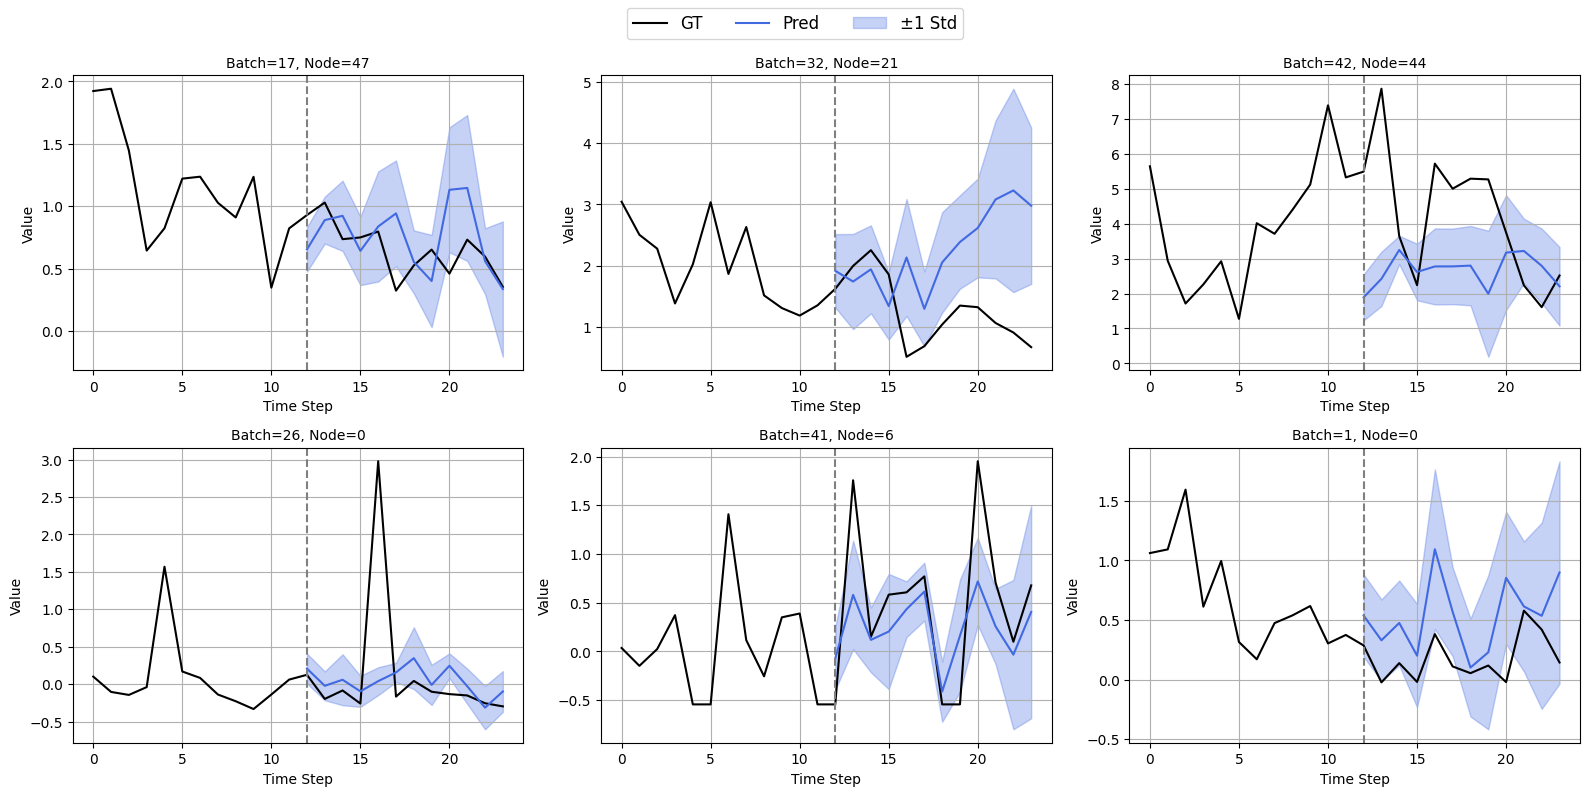

In [6]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import random
import os

# ========== 文件路径 ==========
forecast_path = "/home/guanghui/DiffODE/output/forecast/UGnet+32+200+quad+0.1+200+ddpm+12+8+True+COVID+0.0+False+False+0.002+8.pkl"

# ========== 加载预测结果 ==========
assert os.path.exists(forecast_path), f"文件不存在: {forecast_path}"

with open(forecast_path, 'rb') as f:
    samples, targets, observed_flag, evaluate_flag = pickle.load(f)

if hasattr(samples, 'numpy'): samples = samples.numpy()
if hasattr(targets, 'numpy'): targets = targets.numpy()

# ========== 参数设置 ==========
T_h = 12
T_p = 12
T_total = T_h + T_p
n_rows, n_cols = 2, 3  # 一共展示 n_rows * n_cols 张图
feature_idx = 0

# ========== 创建画布 ==========
fig, axs = plt.subplots(n_rows, n_cols, figsize=(16, 8))
axs = axs.flatten()

for i in range(n_rows * n_cols):
    # 随机选取 batch 和 node
    batch_idx = random.randint(0, samples.shape[0] - 1)
    node_idx = random.randint(0, samples.shape[3] - 1)

    gt = targets[batch_idx, :, node_idx, feature_idx]
    preds = samples[batch_idx, :, :, node_idx, feature_idx]
    pred_mean = preds.mean(axis=0)
    pred_std = preds.std(axis=0)

    ax = axs[i]
    ax.plot(range(T_total), gt, label='GT', color='black', linewidth=1.5)
    ax.plot(range(T_h, T_total), pred_mean[T_h:], label='Pred', color='royalblue', linewidth=1.5)
    ax.fill_between(
        range(T_h, T_total),
        pred_mean[T_h:] - pred_std[T_h:],
        pred_mean[T_h:] + pred_std[T_h:],
        color='royalblue', alpha=0.3, label='±1 Std'
    )
    ax.axvline(T_h, color='gray', linestyle='--')
    ax.set_title(f'Batch={batch_idx}, Node={node_idx}', fontsize=10)
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Value')
    ax.grid(True)

# 去重 legend，最后统一显示
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=12)
# fig.suptitle("DiffSTG: Ground Truth vs Predicted Sequences", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('./output.png')
plt.show()

nvidia-smi > /home/guanghui/DiffODE/output/gpustat//gpustat.txt
wrong in load gpu info dict list index out of range
None gpu is avalible, try again later


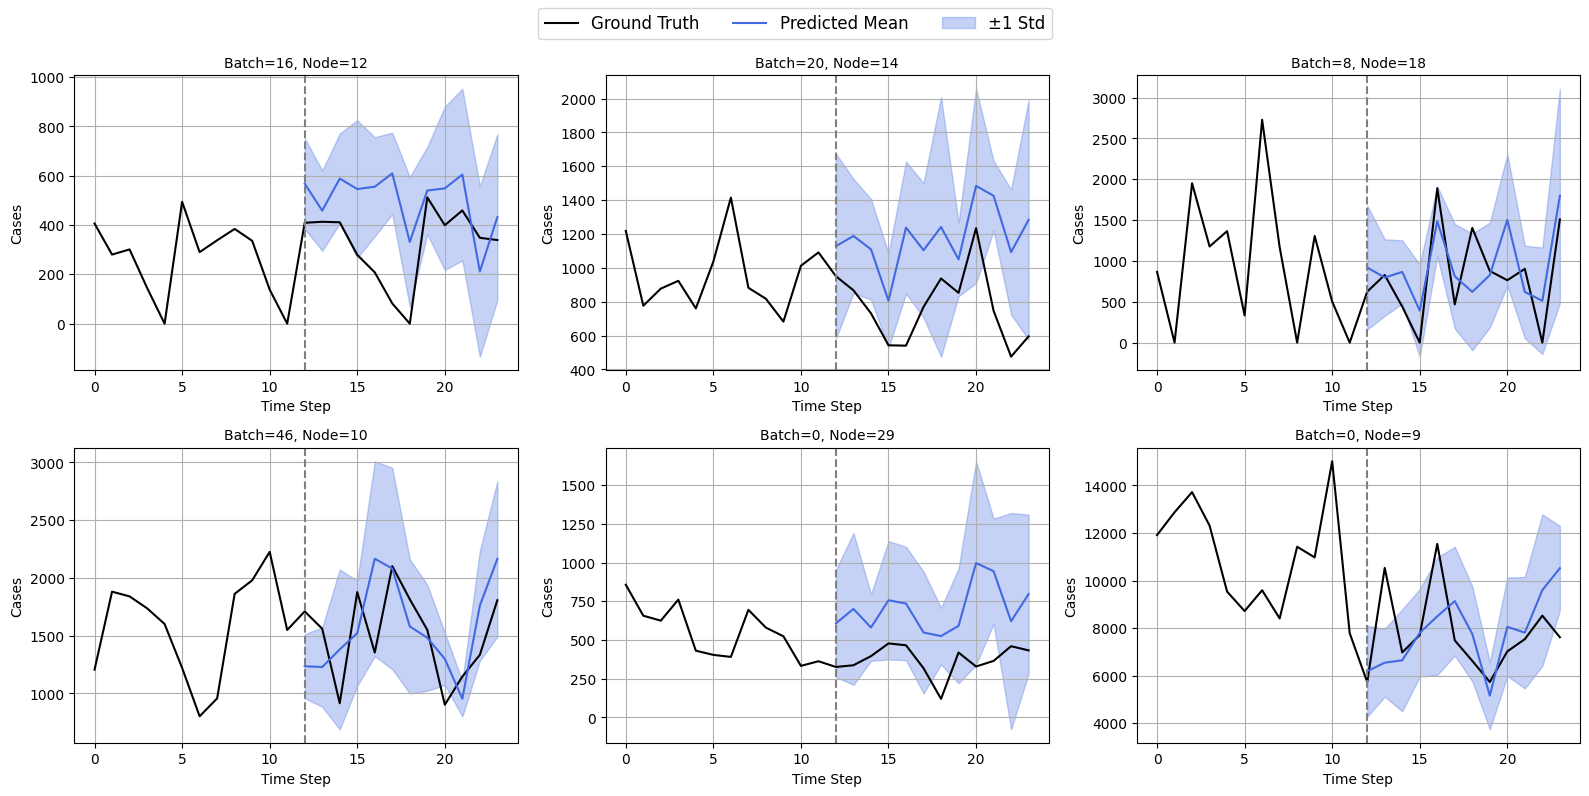

In [19]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import sys

# === 引入 clean_data 对象以获取 mean/std ===
sys.path.append('/home/guanghui/DiffODE/')  # 替换为你的项目路径
from algorithm.dataset import CleanDataset
from train import default_config

# === 路径设置 ===
forecast_path = "/home/guanghui/DiffODE/output/forecast/UGnet+32+200+quad+0.1+200+ddpm+12+8+True+COVID+0.0+False+False+0.002+8.pkl"
assert os.path.exists(forecast_path), f"预测文件不存在: {forecast_path}"

# === 加载预测数据 ===
with open(forecast_path, 'rb') as f:
    samples, targets, observed_flag, evaluate_flag = pickle.load(f)

# === 若为 Tensor 转为 NumPy ===
if hasattr(samples, 'numpy'): samples = samples.numpy()
if hasattr(targets, 'numpy'): targets = targets.numpy()

# === 加载 CleanDataset 以访问 mean 和 std ===
config = default_config(data='COVID')
clean_data = CleanDataset(config)

# === 执行还原（反标准化）===
mean = clean_data.mean
std = clean_data.std
samples = samples * std + mean
targets = targets * std + mean

# === 可视化多个预测段 ===
T_h = 12
T_p = 12
T_total = T_h + T_p
n_rows, n_cols = 2, 3
feature_idx = 0

fig, axs = plt.subplots(n_rows, n_cols, figsize=(16, 8))
axs = axs.flatten()

for i in range(n_rows * n_cols):
    batch_idx = random.randint(0, samples.shape[0] - 1)
    node_idx = random.randint(0, samples.shape[3] - 1)

    gt = targets[batch_idx, :, node_idx, feature_idx]
    preds = samples[batch_idx, :, :, node_idx, feature_idx]
    pred_mean = preds.mean(axis=0)
    pred_std = preds.std(axis=0)

    ax = axs[i]
    ax.plot(range(T_total), gt, label='Ground Truth', color='black', linewidth=1.5)
    ax.plot(range(T_h, T_total), pred_mean[T_h:], label='Predicted Mean', color='royalblue', linewidth=1.5)
    ax.fill_between(
        range(T_h, T_total),
        pred_mean[T_h:] - pred_std[T_h:],
        pred_mean[T_h:] + pred_std[T_h:],
        color='royalblue', alpha=0.3, label='±1 Std'
    )
    ax.axvline(T_h, color='gray', linestyle='--')
    ax.set_title(f'Batch={batch_idx}, Node={node_idx}', fontsize=10)
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Cases')
    ax.grid(True)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=12)
# fig.suptitle("DiffSTG: Ground Truth vs Predicted Sequences (Original Scale)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('./output.png')
plt.show()